In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report,
                              confusion_matrix)
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE
from matplotlib.patches import Patch


In [2]:
df = pd.read_csv('student-mat.csv', sep=';')

print("Shape:", df.shape)
("Columns:", list(df.columns))   
df.head(10)

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [3]:
# RENAME COLUMNS
df.columns = [
    'school_name', 'gender', 'age', 'home_location', 'family_size',
    'parents_living_together', 'mother_education', 'father_education',
    'mother_job', 'father_job', 'reason_choosing_school', 'who_is_guardian',
    'travel_time_to_school', 'weekly_study_time', 'past_failures',
    'extra_school_support', 'family_study_support', 'paid_extra_classes',
    'extracurricular_activities', 'attended_nursery', 'wants_higher_education',
    'has_internet', 'in_romantic_relationship', 'family_relationship_quality',
    'free_time_after_school', 'going_out_with_friends', 'weekday_alcohol_use',
    'weekend_alcohol_use', 'current_health_status', 'school_absences',
    'term1_grade', 'term2_grade', 'final_grade'
]


print("✅ Columns renamed")
print("Shape:", df.shape)
df.head(10)

✅ Columns renamed
Shape: (395, 33)


,school_name,gender,age,home_location,family_size,parents_living_together,mother_education,father_education,mother_job,father_job,...,family_relationship_quality,free_time_after_school,going_out_with_friends,weekday_alcohol_use,weekend_alcohol_use,current_health_status,school_absences,term1_grade,term2_grade,final_grade
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [4]:
# Show ONLY term1, term2, final_grade where final_grade = 0
df[df['final_grade'] == 0][['term1_grade', 'term2_grade', 'final_grade']]

,term1_grade,term2_grade,final_grade
128,7,4,0
130,12,0,0
131,8,0,0
134,9,0,0
135,11,0,0
136,10,0,0
137,4,0,0
140,7,9,0
144,5,0,0
146,6,7,0


In [5]:
df[df['final_grade'] == 0].shape[0]

38

In [6]:
# Remove zero final grades
df = df[df['final_grade'] != 0].reset_index(drop=True)

In [7]:
# ================================================
# DATASET OVERVIEW


print(df.isnull().sum())
print("\n=== Data Types ===")
print(df.dtypes)
print("\n=== Description ===")
df.describe()

school_name                    0
gender                         0
age                            0
home_location                  0
family_size                    0
parents_living_together        0
mother_education               0
father_education               0
mother_job                     0
father_job                     0
reason_choosing_school         0
who_is_guardian                0
travel_time_to_school          0
weekly_study_time              0
past_failures                  0
extra_school_support           0
family_study_support           0
paid_extra_classes             0
extracurricular_activities     0
attended_nursery               0
wants_higher_education         0
has_internet                   0
in_romantic_relationship       0
family_relationship_quality    0
free_time_after_school         0
going_out_with_friends         0
weekday_alcohol_use            0
weekend_alcohol_use            0
current_health_status          0
school_absences                0
term1_grad

,age,mother_education,father_education,travel_time_to_school,weekly_study_time,past_failures,family_relationship_quality,free_time_after_school,going_out_with_friends,weekday_alcohol_use,weekend_alcohol_use,current_health_status,school_absences,term1_grade,term2_grade,final_grade
count,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000,357.000000
mean,16.655462,2.795518,2.546218,1.431373,2.042017,0.271709,3.955182,3.246499,3.098039,1.495798,2.330532,3.549020,6.316527,11.268908,11.358543,11.523810
std,1.268262,1.093999,1.084217,0.686075,0.831895,0.671750,0.885721,1.011601,1.090779,0.919886,1.294974,1.402638,8.187623,3.240450,3.147188,3.227797
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,5.000000,4.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,2.000000,9.000000,9.000000,9.000000
50%,17.000000,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,14.000000,14.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [8]:
# ================================================
# CREATE GRADE BANDS

def assign_grade(g):
    if g < 10:   return 'Fail'
    elif g < 14: return 'Pass'
    elif g < 17: return 'Merit'
    else:        return 'Distinction'

df['grade_band'] = df['final_grade'].apply(assign_grade)

print("Grade Distribution:")
print(df['grade_band'].value_counts())

Grade Distribution:
grade_band
Pass           165
Fail            92
Merit           76
Distinction     24
Name: count, dtype: int64


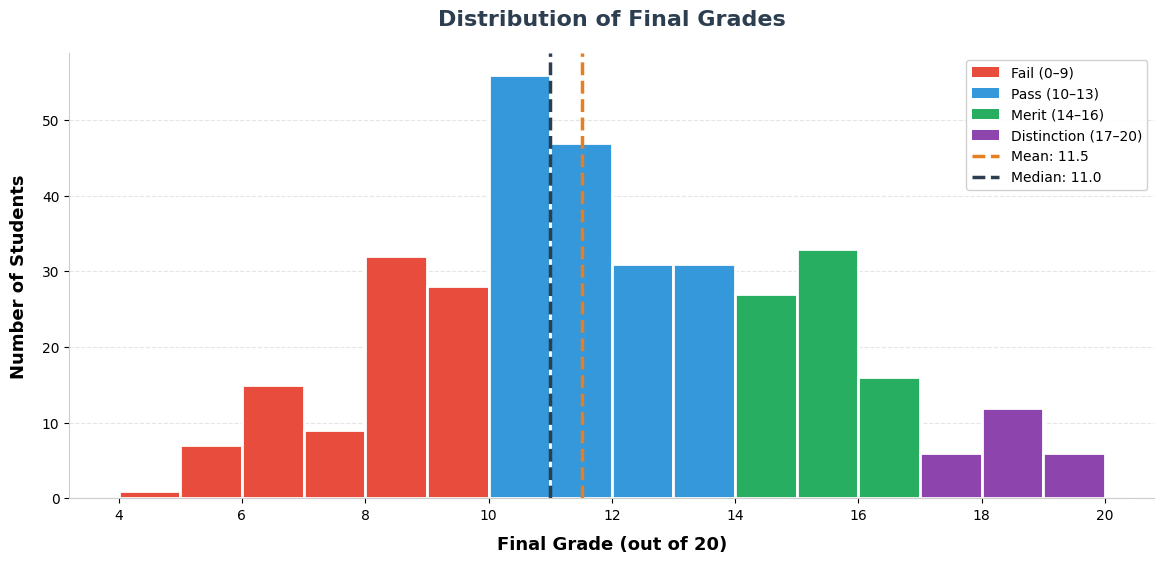

In [9]:
# CHART 1: FINAL GRADE HISTOGRAM
# ================================================
mean_grade   = df['final_grade'].mean()
median_grade = df['final_grade'].median()

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

n, bins, patches = ax.hist(df['final_grade'], bins=16,
                            edgecolor='white', linewidth=2)
for patch, left_edge in zip(patches, bins):
    if   left_edge < 10: patch.set_facecolor('#E74C3C')
    elif left_edge < 14: patch.set_facecolor('#3498DB')
    elif left_edge < 17: patch.set_facecolor('#27AE60')
    else:                patch.set_facecolor('#8E44AD')

ax.axvline(mean_grade,   color='#E67E22', linewidth=2.5,
           linestyle='--', label=f'Mean: {mean_grade:.1f}')
ax.axvline(median_grade, color='#2C3E50', linewidth=2.5,
           linestyle='--', label=f'Median: {median_grade:.1f}')

legend_bands = [
    Patch(facecolor='#E74C3C', label='Fail (0–9)'),
    Patch(facecolor='#3498DB', label='Pass (10–13)'),
    Patch(facecolor='#27AE60', label='Merit (14–16)'),
    Patch(facecolor='#8E44AD', label='Distinction (17–20)'),
    plt.Line2D([0],[0], color='#E67E22', linewidth=2.5,
               linestyle='--', label=f'Mean: {mean_grade:.1f}'),
    plt.Line2D([0],[0], color='#2C3E50', linewidth=2.5,
               linestyle='--', label=f'Median: {median_grade:.1f}')
]
ax.legend(handles=legend_bands, fontsize=10, framealpha=0.9,
          loc='upper right', edgecolor='#CCCCCC')

ax.set_title('Distribution of Final Grades',
             fontsize=16, fontweight='bold', pad=20, color='#2C3E50')
ax.set_xlabel('Final Grade (out of 20)',
              fontsize=13, fontweight='bold', labelpad=10)
ax.set_ylabel('Number of Students',
              fontsize=13, fontweight='bold', labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC')
ax.set_axisbelow(True)
plt.tight_layout(pad=2.0)
plt.savefig('chart1_histogram.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [10]:
df['final_grade'].describe()

count    357.000000
mean      11.523810
std        3.227797
min        4.000000
25%        9.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: final_grade, dtype: float64

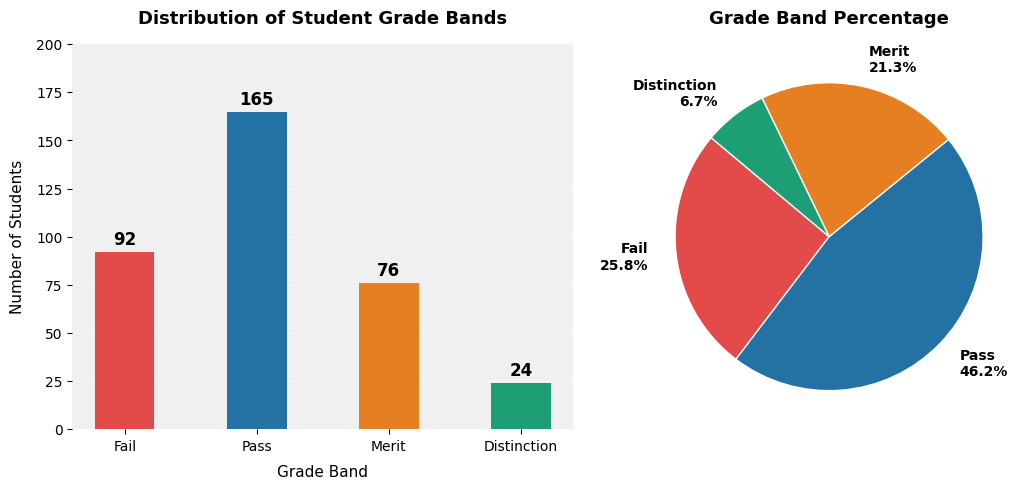

In [11]:
# ================================================
# CHART 2 — GRADE BAND DISTRIBUTION + PIE

counts = df['grade_band'].value_counts().reindex(['Fail', 'Pass', 'Merit', 'Distinction'])
colors = ['#E24B4A', '#2471a3', '#E67E22', '#1D9E75']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')
fig.subplots_adjust(wspace=0.01)

# bar chart
ax1.set_facecolor('#f0f0f0')
bars = ax1.bar(counts.index, counts.values, color=colors,
               width=0.45, edgecolor='none')

for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             str(val), ha='center', fontsize=12, fontweight='bold')

ax1.set_title('Distribution of Student Grade Bands',
              fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel('Grade Band', fontsize=11, labelpad=8)
ax1.set_ylabel('Number of Students', fontsize=11, labelpad=8)
ax1.set_ylim(0, 200)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.yaxis.grid(True, linestyle='-', alpha=0.5, color='white')
ax1.set_axisbelow(True)
ax1.tick_params(axis='both', labelsize=10)

# pie chart
ax2.set_facecolor('#f0f0f0')
labels = [f'{b}\n{p:.1f}%' for b, p in
          zip(counts.index, counts.values/counts.values.sum()*100)]

wedges, texts = ax2.pie(counts.values, labels=labels, colors=colors,
        startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.0},
        textprops={'fontsize': 10, 'fontweight': 'bold'},
        labeldistance=1.18)

ax2.set_title('Grade Band Percentage',
              fontsize=13, fontweight='bold', pad=15)

plt.savefig('grade_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# LABEL ENCODING
# ================================================
categorical_cols = [
    'school_name','gender','home_location','family_size',
    'parents_living_together','mother_job','father_job',
    'reason_choosing_school','who_is_guardian',
    'extra_school_support','family_study_support',
    'paid_extra_classes','extracurricular_activities',
    'attended_nursery','wants_higher_education',
    'has_internet','in_romantic_relationship'
]
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])



In [13]:
# STANDARD SCALING
# ================================================
scale_cols = [
    'age','mother_education','father_education',
    'travel_time_to_school','weekly_study_time',
    'past_failures','family_relationship_quality',
    'free_time_after_school','going_out_with_friends',
    'weekday_alcohol_use','weekend_alcohol_use',
    'current_health_status','school_absences',
    'term1_grade','term2_grade'
]
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("✅ Standard scaling complete")

✅ Standard scaling complete


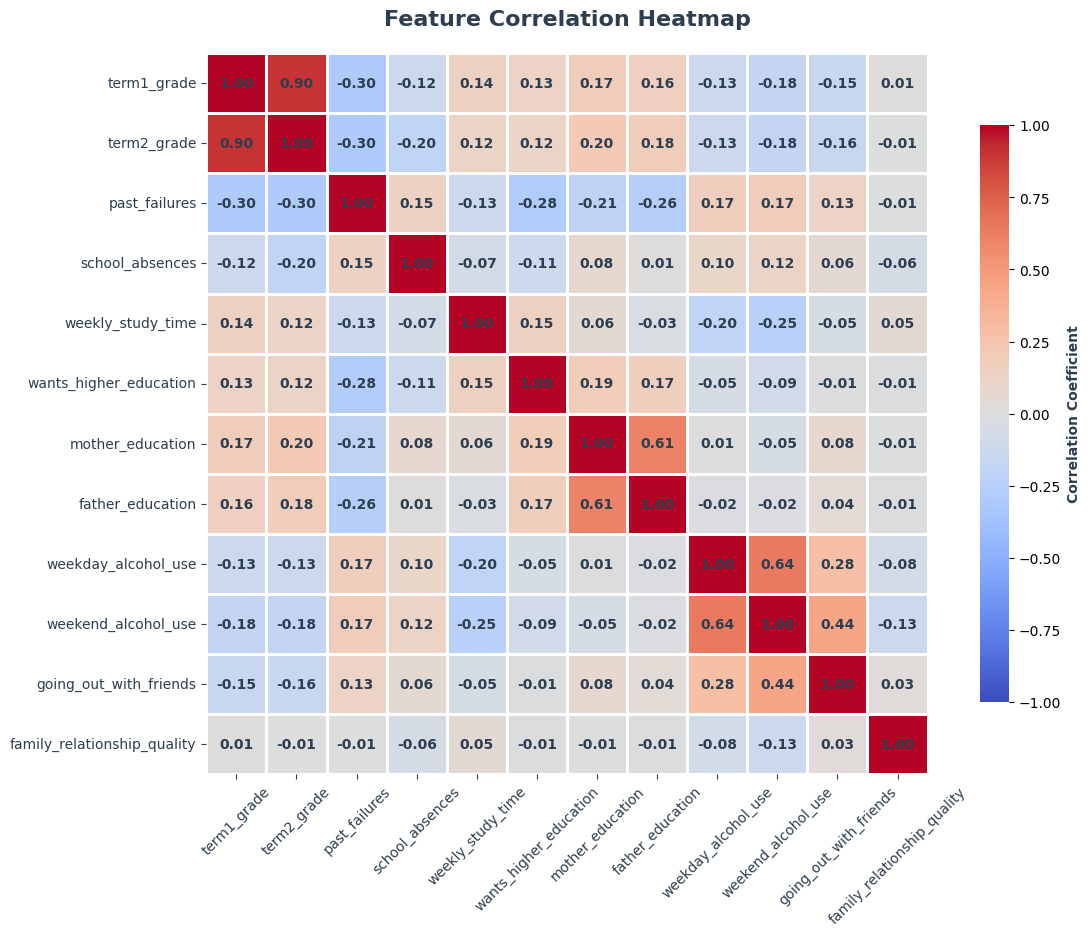

In [14]:
# ================================================
# CHART 3 — FEATURE CORRELATION HEATMAP
# ================================================
important_cols = [
    'term1_grade','term2_grade','past_failures',
    'school_absences','weekly_study_time',
    'wants_higher_education','mother_education',
    'father_education','weekday_alcohol_use',
    'weekend_alcohol_use','going_out_with_friends',
    'family_relationship_quality'
]

fig, ax = plt.subplots(figsize=(13, 10))
fig.patch.set_facecolor('white')

sns.heatmap(df[important_cols].corr(),
            ax=ax,
            cmap='coolwarm',
            center=0,
            vmin=-1, vmax=1,
            linewidths=0.8,
            linecolor='white',
            annot=True,
            fmt='.2f',
            annot_kws={'size': 10, 'weight': 'bold',
                       'color': '#2C3E50'},
            square=True,
            cbar_kws={'shrink': 0.8,
                      'label': 'Correlation Coefficient'})

ax.set_title('Feature Correlation Heatmap',
             fontsize=16, fontweight='bold',
             pad=20, color='#2C3E50')
ax.tick_params(axis='x', rotation=45,
               labelsize=10, colors='#2C3E50')
ax.tick_params(axis='y', rotation=0,
               labelsize=10, colors='#2C3E50')

# Colour bar label style
ax.figure.axes[-1].set_ylabel(
    'Correlation Coefficient',
    fontsize=10, fontweight='bold', color='#2C3E50')

plt.tight_layout(pad=3.0)
plt.savefig('chart3_correlation_heatmap.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [15]:
# FEATURE ENGINEERING (6 new features)
# ================================================
df['alcohol_total']  = (df['weekday_alcohol_use'] +
                        df['weekend_alcohol_use'])
df['parent_edu_avg'] = ((df['mother_education'] +
                         df['father_education']) / 2)
df['grade_progress'] = df['term2_grade'] - df['term1_grade']
df['social_risk']    = (df['going_out_with_friends'] +
                        df['weekday_alcohol_use'] +
                        df['weekend_alcohol_use'])
df['study_focus']    = (df['weekly_study_time'] -
                        df['going_out_with_friends'])
df['risk_score']     = df['past_failures'] * df['school_absences']

print("✅ 6 new features created. Shape:", df.shape)

✅ 6 new features created. Shape: (357, 40)


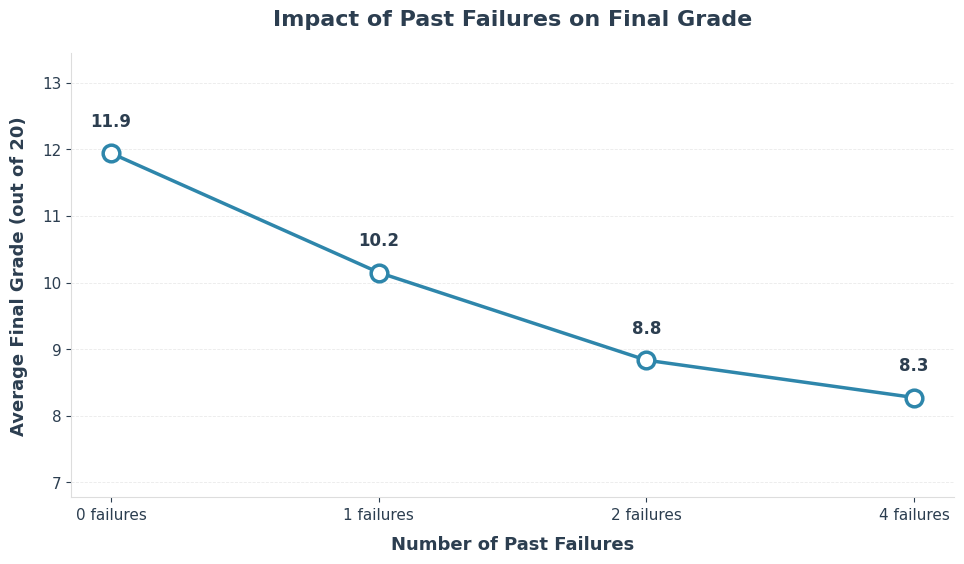

In [16]:
# ================================================
# CHART 4 — PAST FAILURES vs FINAL GRADE
# ================================================
failures_grade = (df.groupby('past_failures')['final_grade']
                  .mean().reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

ax.plot(failures_grade['past_failures'],
        failures_grade['final_grade'],
        color='#2E86AB', marker='o', linewidth=2.5,
        markersize=12, markerfacecolor='white',
        markeredgewidth=2.5, markeredgecolor='#2E86AB',
        zorder=5)

for x, y in zip(failures_grade['past_failures'],
                failures_grade['final_grade']):
    ax.text(x, y + 0.4, f'{y:.1f}',
            ha='center', fontweight='bold',
            fontsize=12, color='#2C3E50')

ax.set_title('Impact of Past Failures on Final Grade',
             fontsize=16, fontweight='bold',
             pad=20, color='#2C3E50')
ax.set_xlabel('Number of Past Failures',
              fontsize=13, fontweight='bold',
              labelpad=10, color='#2C3E50')
ax.set_ylabel('Average Final Grade (out of 20)',
              fontsize=13, fontweight='bold',
              labelpad=10, color='#2C3E50')
ax.set_xticks(failures_grade['past_failures'])
ax.set_xticklabels(
    [f'{int(x)} failure{"s" if x != 1 else ""}'
     for x in failures_grade['past_failures']],
    fontsize=11)
ax.set_ylim(
    failures_grade['final_grade'].min() - 1.5,
    failures_grade['final_grade'].max() + 1.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#DDDDDD')
ax.spines['bottom'].set_color('#DDDDDD')
ax.yaxis.grid(True, linestyle='--',
              linewidth=0.6, alpha=0.6, color='#DDDDDD')
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11,
               colors='#2C3E50')
plt.tight_layout(pad=2.0)
plt.savefig('chart4_failures_grade.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

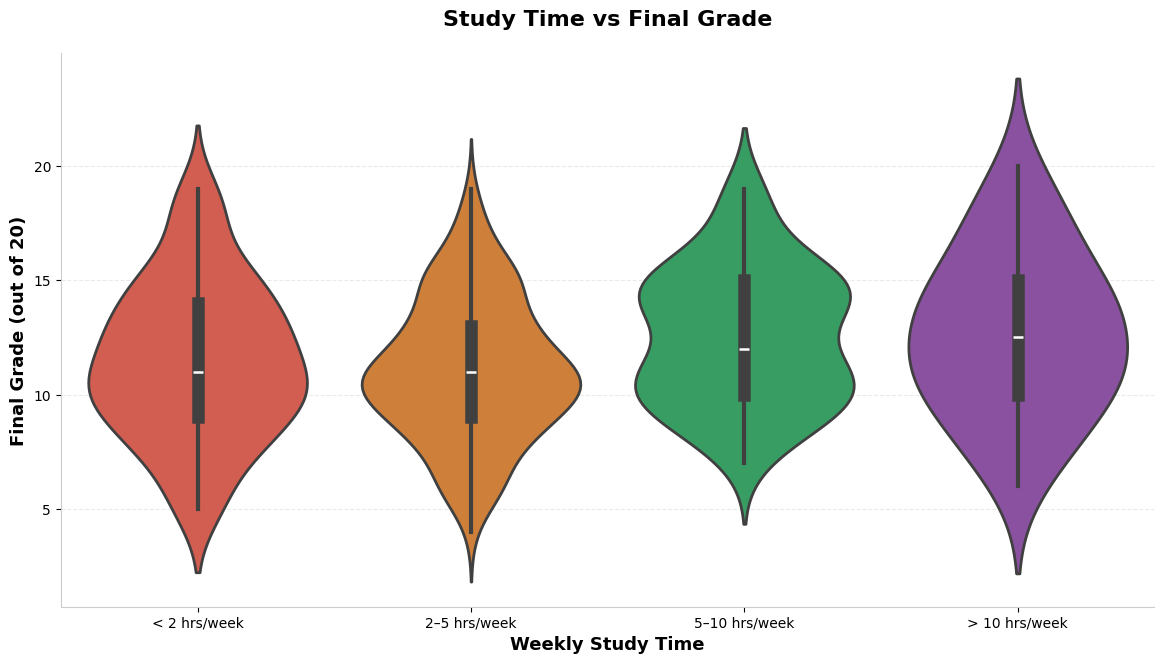

In [17]:
# CHART 5: STUDY TIME VIOLIN
# ================================================
vals = sorted(df['weekly_study_time'].unique())
label_map = {vals[0]:'< 2 hrs/week', vals[1]:'2–5 hrs/week',
             vals[2]:'5–10 hrs/week', vals[3]:'> 10 hrs/week'}
df['study_label'] = df['weekly_study_time'].map(label_map)
study_order = ['< 2 hrs/week','2–5 hrs/week',
               '5–10 hrs/week','> 10 hrs/week']
palette = {'< 2 hrs/week':'#E74C3C','2–5 hrs/week':'#E67E22',
           '5–10 hrs/week':'#27AE60','> 10 hrs/week':'#8E44AD'}

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

sns.violinplot(data=df, x='study_label', y='final_grade',
               order=study_order, hue='study_label',
               palette=palette, inner='box',
               linewidth=2, legend=False, ax=ax)

ax.set_title('Study Time vs Final Grade',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Weekly Study Time',
              fontsize=13, fontweight='bold')
ax.set_ylabel('Final Grade (out of 20)',
              fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
plt.tight_layout(pad=2.0)
plt.savefig('chart5_study_violin.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [18]:
# SPLIT 

X = df.drop(columns=['final_grade','grade_band','study_label'])
y = df['grade_band']

# STEP 1: SPLIT FIRST
X_train_raw, X_test, y_train_raw, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Before SMOTE:")
print(f"  Train: {X_train_raw.shape[0]} samples")
print(f"  Test:  {X_test.shape[0]} samples")
print(y_train_raw.value_counts())

# STEP 2: SMOTE ON TRAIN ONLY
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)

print("\nAfter SMOTE (train only):")
print(f"  Train: {X_train_res.shape[0]} samples")
print(pd.Series(y_train_res).value_counts())
print(f"\nTest unchanged: {X_test.shape[0]} samples")

Before SMOTE:
  Train: 285 samples
  Test:  72 samples
grade_band
Pass           132
Fail            73
Merit           61
Distinction     19
Name: count, dtype: int64

After SMOTE (train only):
  Train: 528 samples
grade_band
Fail           132
Pass           132
Merit          132
Distinction    132
Name: count, dtype: int64

Test unchanged: 72 samples


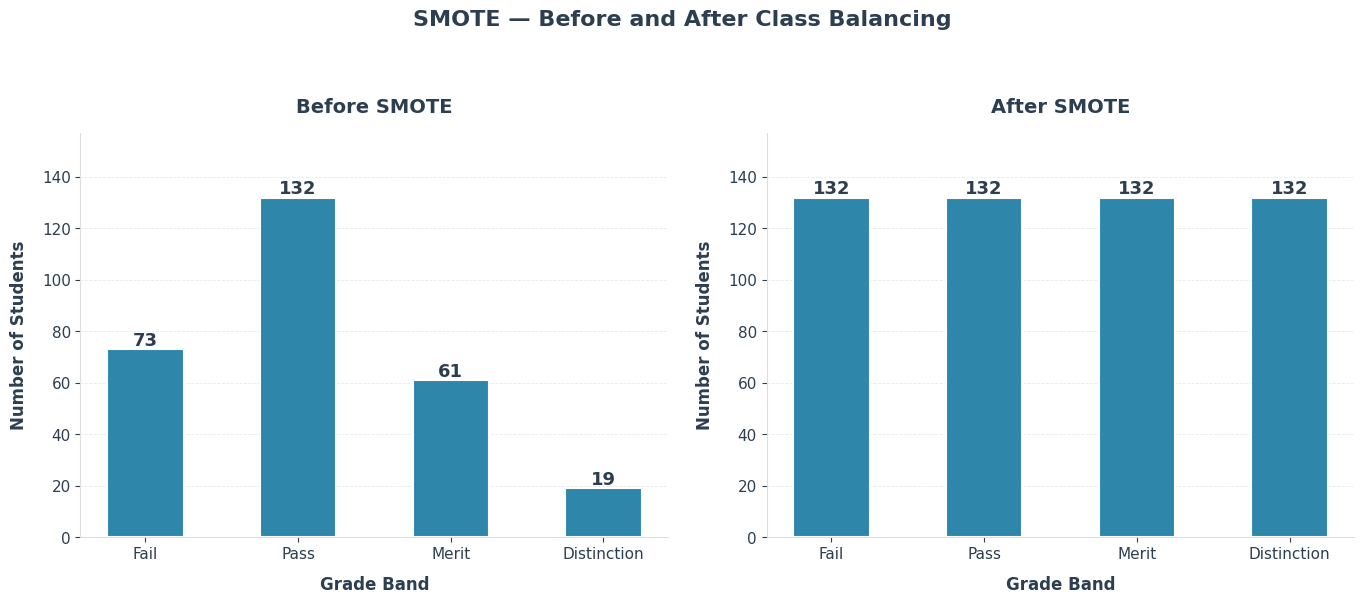

In [19]:
# ================================================
# CHART 6 — SMOTE CLASS BALANCING
# ================================================
band_order    = ['Fail', 'Pass', 'Merit', 'Distinction']
before_counts = y_train_raw.value_counts().reindex(band_order)
after_counts  = pd.Series(y_train_res).value_counts().reindex(band_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

for ax, data, title in zip(
    [ax1, ax2],
    [before_counts, after_counts],
    ['Before SMOTE', 'After SMOTE']):

    ax.set_facecolor('white')
    bars = ax.bar(band_order, data.values,
                  color='#2E86AB',
                  width=0.5,
                  edgecolor='white',
                  linewidth=1.5)

    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                str(int(val)),
                ha='center', fontsize=13,
                fontweight='bold', color='#2C3E50')

    ax.set_title(title, fontsize=14,
                 fontweight='bold',
                 pad=15, color='#2C3E50')
    ax.set_xlabel('Grade Band', fontsize=12,
                  fontweight='bold',
                  labelpad=10, color='#2C3E50')
    ax.set_ylabel('Number of Students', fontsize=12,
                  fontweight='bold',
                  labelpad=10, color='#2C3E50')
    ax.set_ylim(0, max(data.values) + 25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#DDDDDD')
    ax.spines['bottom'].set_color('#DDDDDD')
    ax.yaxis.grid(True, linestyle='--',
                  linewidth=0.6, alpha=0.6,
                  color='#DDDDDD')
    ax.xaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis='both', labelsize=11,
                   colors='#2C3E50')

fig.suptitle('SMOTE — Before and After Class Balancing',
             fontsize=16, fontweight='bold',
             y=1.02, color='#2C3E50')
plt.tight_layout(pad=2.0)
plt.savefig('chart6_smote.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [20]:
# CELL 15 — RFE FEATURE SELECTION

rfe_model = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rfe_model, n_features_to_select=15)
rfe.fit(X_train_res, y_train_res)

selected_features = X_train_res.columns[rfe.support_].tolist()
X_train_sel = X_train_res[selected_features]
X_test_sel  = X_test[selected_features]

print(f"✅ Features: {X.shape[1]} → {len(selected_features)} selected")
print("Selected:", selected_features)

✅ Features: 38 → 15 selected
Selected: ['age', 'mother_education', 'weekly_study_time', 'past_failures', 'family_relationship_quality', 'current_health_status', 'school_absences', 'term1_grade', 'term2_grade', 'alcohol_total', 'parent_edu_avg', 'grade_progress', 'social_risk', 'study_focus', 'risk_score']


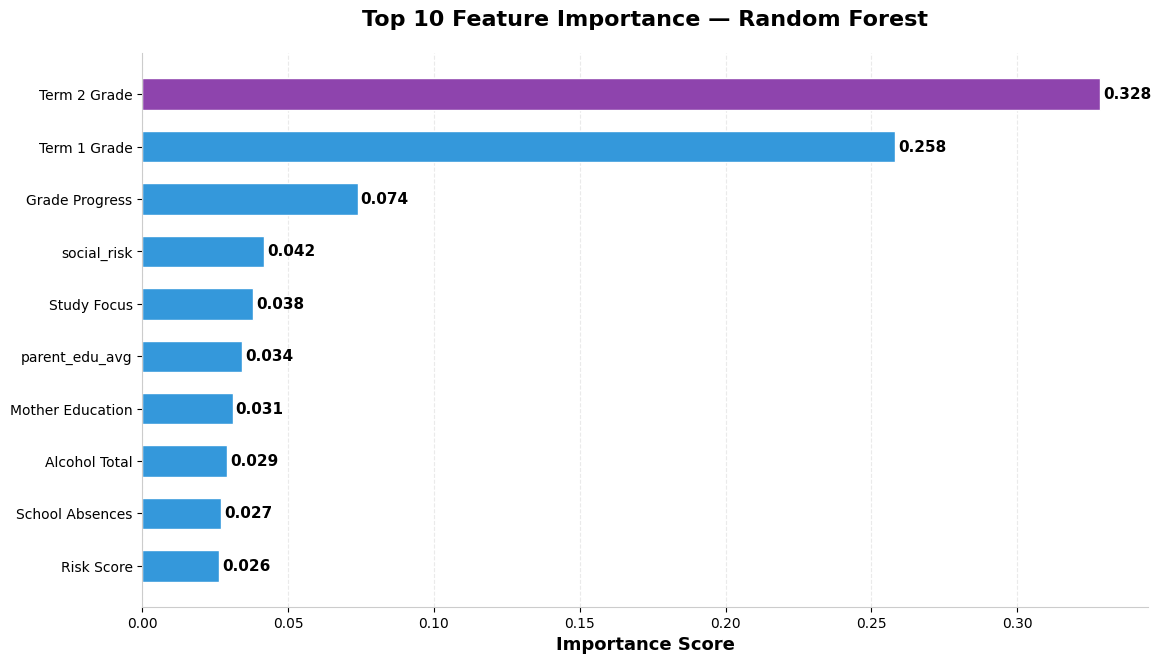

In [21]:
# CELL 16 — CHART 7: FEATURE IMPORTANCE
# ================================================
rf_imp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_imp.fit(X_train_sel, y_train_res)

importance = (pd.Series(rf_imp.feature_importances_,
                         index=selected_features)
              .sort_values(ascending=False)
              .head(10)
              .sort_values(ascending=True))

clean_names = {
    'school_absences':'School Absences',
    'mother_education':'Mother Education',
    'weekend_alcohol_use':'Weekend Alcohol Use',
    'going_out_with_friends':'Going Out with Friends',
    'weekly_study_time':'Weekly Study Time',
    'current_health_status':'Current Health Status',
    'father_education':'Father Education',
    'age':'Age',
    'free_time_after_school':'Free Time After School',
    'term1_grade':'Term 1 Grade',
    'term2_grade':'Term 2 Grade',
    'grade_progress':'Grade Progress',
    'risk_score':'Risk Score',
    'study_focus':'Study Focus',
    'alcohol_total':'Alcohol Total'
}
importance.index = [clean_names.get(i,i) for i in importance.index]

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bar_colors = ['#8E44AD' if v == importance.max()
              else '#3498DB' for v in importance.values]
bars = ax.barh(importance.index, importance.values,
               color=bar_colors, height=0.6,
               edgecolor='white', linewidth=1)
for bar, val in zip(bars, importance.values):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center',
            fontsize=11, fontweight='bold')

ax.set_title('Top 10 Feature Importance — Random Forest',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Importance Score', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
plt.tight_layout(pad=2.0)
plt.savefig('chart7_feature_importance.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [22]:
# TRAIN 3 MODELS 

# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=5000)
lr_model.fit(X_train_sel, y_train_res)
y_pred_lr = lr_model.predict(X_test_sel)
print("✅ Logistic Regression trained")

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_sel, y_train_res)
y_pred_dt = dt_model.predict(X_test_sel)
print("✅ Decision Tree trained")

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_sel, y_train_res)
y_pred_rf = rf_model.predict(X_test_sel)
print("✅ Random Forest trained")

✅ Logistic Regression trained
✅ Decision Tree trained
✅ Random Forest trained


In [23]:
# HYPERPARAMETER TUNING — GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5,
    scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train_sel, y_train_res)
grid_search.best_params_

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

In [24]:
# ================================================
# CELL 18 — COMPUTE ALL REAL METRICS
# ================================================
lr_acc = accuracy_score(y_test, y_pred_lr)
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

lr_f1  = f1_score(y_test, y_pred_lr, average='weighted')
dt_f1  = f1_score(y_test, y_pred_dt, average='weighted')
rf_f1  = f1_score(y_test, y_pred_rf, average='weighted')

lr_pr  = precision_score(y_test, y_pred_lr, average='weighted')
dt_pr  = precision_score(y_test, y_pred_dt, average='weighted')
rf_pr  = precision_score(y_test, y_pred_rf, average='weighted')

lr_re  = recall_score(y_test, y_pred_lr, average='weighted')
dt_re  = recall_score(y_test, y_pred_dt, average='weighted')
rf_re  = recall_score(y_test, y_pred_rf, average='weighted')

lr_cv  = cross_val_score(lr_model, X_train_sel,
                          y_train_res, cv=10).mean()
dt_cv  = cross_val_score(dt_model, X_train_sel,
                          y_train_res, cv=10).mean()
rf_cv  = cross_val_score(rf_model, X_train_sel,
                          y_train_res, cv=10).mean()

print("✅ All metrics computed")
print(f"LR:  {lr_acc:.2%} | DT: {dt_acc:.2%} | RF: {rf_acc:.2%}")

✅ All metrics computed
LR:  81.94% | DT: 76.39% | RF: 86.11%


In [25]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [f'{lr_acc:.2%}', f'{dt_acc:.2%}', f'{rf_acc:.2%}'],
    'CV Score': [f'{lr_cv:.2%}', f'{dt_cv:.2%}', f'{rf_cv:.2%}'],
    'F1 Score': [
        f'{f1_score(y_test, y_pred_lr, average="weighted"):.2%}',
        f'{f1_score(y_test, y_pred_dt, average="weighted"):.2%}',
        f'{f1_score(y_test, y_pred_rf, average="weighted"):.2%}'
    ],
    'Precision': [
        f'{precision_score(y_test, y_pred_lr, average="weighted"):.2%}',
        f'{precision_score(y_test, y_pred_dt, average="weighted"):.2%}',
        f'{precision_score(y_test, y_pred_rf, average="weighted"):.2%}'
    ],
    'Recall': [
        f'{recall_score(y_test, y_pred_lr, average="weighted"):.2%}',
        f'{recall_score(y_test, y_pred_dt, average="weighted"):.2%}',
        f'{recall_score(y_test, y_pred_rf, average="weighted"):.2%}'
    ]
}).style.set_table_styles([
    {'selector': 'th', 'props': [
        ('background-color', '#2E86AB'),
        ('color', 'white'),
        ('font-weight', 'bold'),
        ('font-size', '16px'),
        ('padding', '14px'),
        ('text-align', 'center')]},
    {'selector': 'td', 'props': [
        ('font-size', '15px'),
        ('font-weight', 'bold'),
        ('padding', '12px'),
        ('text-align', 'center'),
        ('border-bottom', '1px solid #ddd')]},
    {'selector': 'caption', 'props': [
        ('font-size', '16px'),
        ('font-weight', 'bold'),
        ('padding', '10px'),
        ('text-align', 'center')]},
    {'selector': 'tr:hover', 'props': [
        ('background-color', '#f0f8ff')]}
]).set_caption('Model Performance Comparison')\
  .hide(axis='index')

results

Model,Accuracy,CV Score,F1 Score,Precision,Recall
Logistic Regression,81.94%,90.16%,81.96%,82.28%,81.94%
Decision Tree,76.39%,87.90%,76.50%,77.81%,76.39%
Random Forest,86.11%,91.69%,86.02%,87.33%,86.11%


In [26]:
# CLASSIFICATION REPORTS
# ================================================
print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(classification_report(y_test, y_pred_lr))

print("=" * 50)
print("DECISION TREE")
print("=" * 50)
print(classification_report(y_test, y_pred_dt))

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(classification_report(y_test, y_pred_rf))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

 Distinction       0.67      0.80      0.73         5
        Fail       0.81      0.89      0.85        19
       Merit       0.79      0.73      0.76        15
        Pass       0.87      0.82      0.84        33

    accuracy                           0.82        72
   macro avg       0.78      0.81      0.79        72
weighted avg       0.82      0.82      0.82        72

DECISION TREE
              precision    recall  f1-score   support

 Distinction       0.50      0.80      0.62         5
        Fail       0.75      0.79      0.77        19
       Merit       0.82      0.60      0.69        15
        Pass       0.82      0.82      0.82        33

    accuracy                           0.76        72
   macro avg       0.72      0.75      0.72        72
weighted avg       0.78      0.76      0.76        72

RANDOM FOREST
              precision    recall  f1-score   support

 Distinction       0.62    

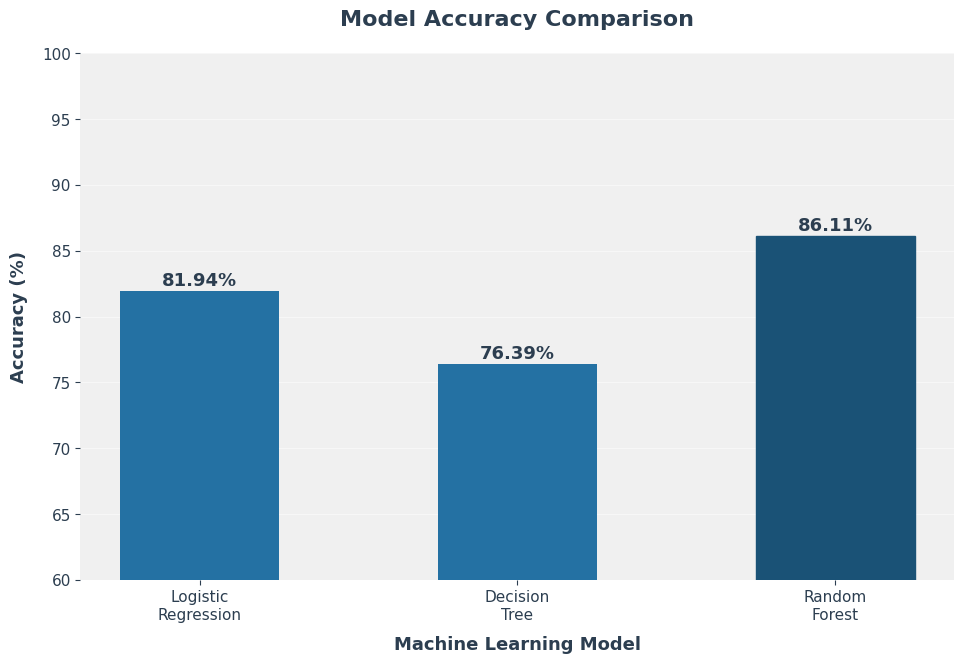

In [27]:
# ================================================
# CHART 8 — MODEL ACCURACY COMPARISON
# ================================================
models_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
accuracies   = [lr_acc*100, dt_acc*100, rf_acc*100]

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f0f0f0')

bars = ax.bar(models_names, accuracies,
              color='#2471a3',
              width=0.5,
              edgecolor='none')

# Highlight best model darker
best_idx = accuracies.index(max(accuracies))
bars[best_idx].set_color('#1a5276')

for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.4,
            f'{val:.2f}%',
            ha='center', fontsize=13,
            fontweight='bold', color='#2C3E50')

ax.set_title('Model Accuracy Comparison',
             fontsize=16, fontweight='bold',
             pad=20, color='#2C3E50')
ax.set_xlabel('Machine Learning Model',
              fontsize=13, fontweight='bold',
              labelpad=10, color='#2C3E50')
ax.set_ylabel('Accuracy (%)',
              fontsize=13, fontweight='bold',
              labelpad=10, color='#2C3E50')
ax.set_ylim(60, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.yaxis.grid(True, linestyle='-',
              alpha=0.5, color='white')
ax.set_axisbelow(True)
ax.tick_params(axis='both', labelsize=11,
               colors='#2C3E50')
plt.tight_layout(pad=2.0)
plt.savefig('chart8_model_accuracy.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

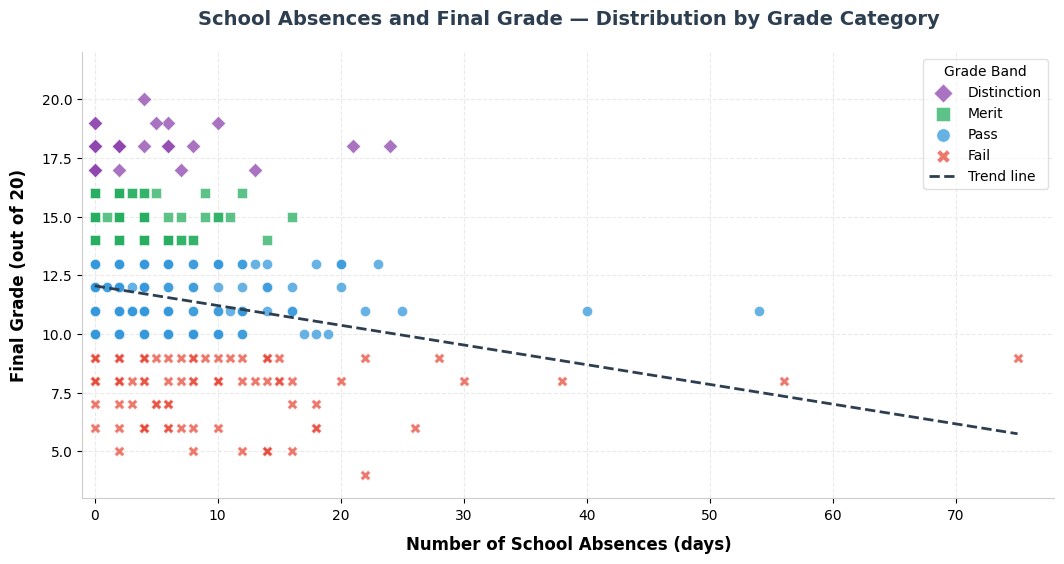

In [28]:
# CHART 9 — SCHOOL ABSENCES vs FINAL GRADE
# ================================================
import numpy as np

# Load fresh original data — avoids any scaling issue
df_abs = pd.read_csv('student-mat.csv', sep=';')
df_abs.columns = [
    'school_name', 'gender', 'age', 'home_location', 'family_size',
    'parents_living_together', 'mother_education', 'father_education',
    'mother_job', 'father_job', 'reason_choosing_school', 'who_is_guardian',
    'travel_time_to_school', 'weekly_study_time', 'past_failures',
    'extra_school_support', 'family_study_support', 'paid_extra_classes',
    'extracurricular_activities', 'attended_nursery', 'wants_higher_education',
    'has_internet', 'in_romantic_relationship', 'family_relationship_quality',
    'free_time_after_school', 'going_out_with_friends', 'weekday_alcohol_use',
    'weekend_alcohol_use', 'current_health_status', 'school_absences',
    'term1_grade', 'term2_grade', 'final_grade'
]
df_abs = df_abs[df_abs['final_grade'] != 0].reset_index(drop=True)

def assign_grade(g):
    if g < 10:   return 'Fail'
    elif g < 14: return 'Pass'
    elif g < 17: return 'Merit'
    else:        return 'Distinction'

df_abs['grade_band'] = df_abs['final_grade'].apply(assign_grade)

colors_map  = {'Fail': '#E74C3C', 'Pass': '#3498DB',
               'Merit': '#27AE60', 'Distinction': '#8E44AD'}
markers_map = {'Distinction': 'D', 'Merit': 's',
               'Pass': 'o',       'Fail': 'X'}
band_order  = ['Distinction', 'Merit', 'Pass', 'Fail']

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for band in band_order:
    group = df_abs[df_abs['grade_band'] == band]
    ax.scatter(group['school_absences'], group['final_grade'],
               color=colors_map[band], marker=markers_map[band],
               label=band, alpha=0.75, s=55,
               edgecolors='white', linewidths=0.5)

z      = np.polyfit(df_abs['school_absences'], df_abs['final_grade'], 1)
p_line = np.poly1d(z)
x_line = np.linspace(0, df_abs['school_absences'].max(), 100)
ax.plot(x_line, p_line(x_line),
        color='#2C3E50', linewidth=2.0,
        linestyle='--', label='Trend line', zorder=5)

ax.set_title('School Absences and Final Grade — Distribution by Grade Category',
             fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
ax.set_xlabel('Number of School Absences (days)',
              fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Final Grade (out of 20)',
              fontsize=12, fontweight='bold', labelpad=10)
ax.set_xlim(-1, df_abs['school_absences'].max() + 3)
ax.set_ylim(3, 22)
ax.legend(fontsize=10, framealpha=0.6, loc='upper right',
          markerscale=1.3, edgecolor='#CCCCCC',
          title='Grade Band', title_fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
plt.tight_layout(pad=2.0)
plt.savefig('chart9_absences_scatter.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

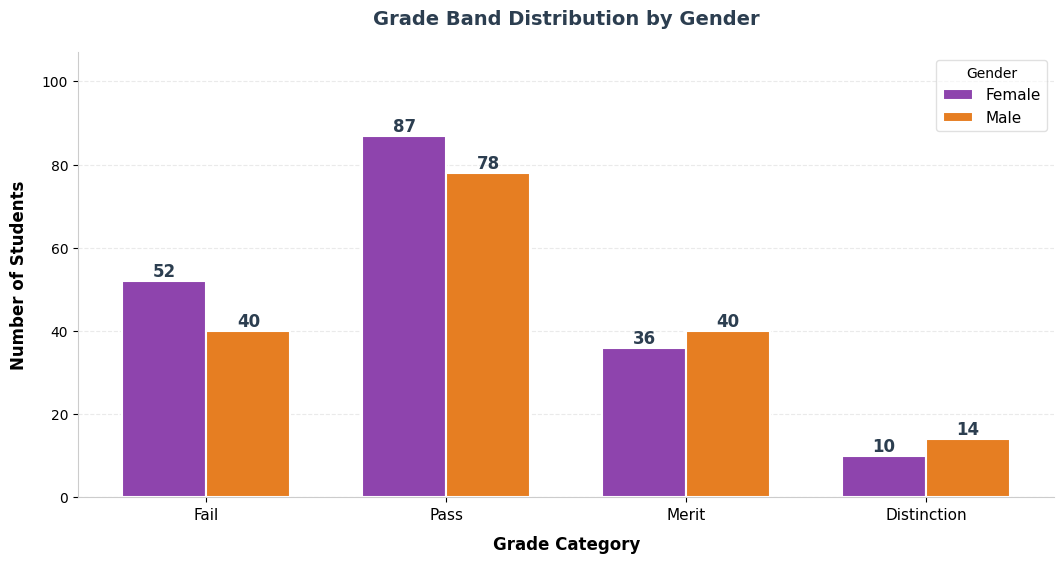

In [29]:
# ================================================
# CHART 10 — GRADE DISTRIBUTION BY GENDER
# ================================================

# Load fresh original data — avoids scaling issue
df_gen = pd.read_csv('student-mat.csv', sep=';')
df_gen.columns = [
    'school_name', 'gender', 'age', 'home_location', 'family_size',
    'parents_living_together', 'mother_education', 'father_education',
    'mother_job', 'father_job', 'reason_choosing_school', 'who_is_guardian',
    'travel_time_to_school', 'weekly_study_time', 'past_failures',
    'extra_school_support', 'family_study_support', 'paid_extra_classes',
    'extracurricular_activities', 'attended_nursery', 'wants_higher_education',
    'has_internet', 'in_romantic_relationship', 'family_relationship_quality',
    'free_time_after_school', 'going_out_with_friends', 'weekday_alcohol_use',
    'weekend_alcohol_use', 'current_health_status', 'school_absences',
    'term1_grade', 'term2_grade', 'final_grade'
]
df_gen = df_gen[df_gen['final_grade'] != 0].reset_index(drop=True)

def assign_grade(g):
    if g < 10:   return 'Fail'
    elif g < 14: return 'Pass'
    elif g < 17: return 'Merit'
    else:        return 'Distinction'

df_gen['grade_band'] = df_gen['final_grade'].apply(assign_grade)

# gender column here is still 'F'/'M' — use original string values
band_order = ['Fail', 'Pass', 'Merit', 'Distinction']
female = df_gen[df_gen['gender'] == 'F']['grade_band'].value_counts().reindex(band_order).fillna(0)
male   = df_gen[df_gen['gender'] == 'M']['grade_band'].value_counts().reindex(band_order).fillna(0)

x = np.arange(len(band_order))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars1 = ax.bar(x - w/2, female.values, width=w,
               color='#8E44AD', edgecolor='white',
               linewidth=1.5, label='Female')
bars2 = ax.bar(x + w/2, male.values, width=w,
               color='#E67E22', edgecolor='white',
               linewidth=1.5, label='Male')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            str(int(bar.get_height())),
            ha='center', fontsize=12,
            fontweight='bold', color='#2C3E50')

ax.set_title('Grade Band Distribution by Gender',
             fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
ax.set_xlabel('Grade Category',
              fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Number of Students',
              fontsize=12, fontweight='bold', labelpad=10)
ax.set_xticks(x)
ax.set_xticklabels(band_order, fontsize=11)
ax.set_ylim(0, max(female.max(), male.max()) + 20)
ax.legend(fontsize=11, framealpha=0.6, loc='upper right',
          title='Gender', title_fontsize=10, edgecolor='#CCCCCC')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
plt.yticks(fontsize=10)
plt.tight_layout(pad=2.0)
plt.savefig('chart10_gender_grade.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

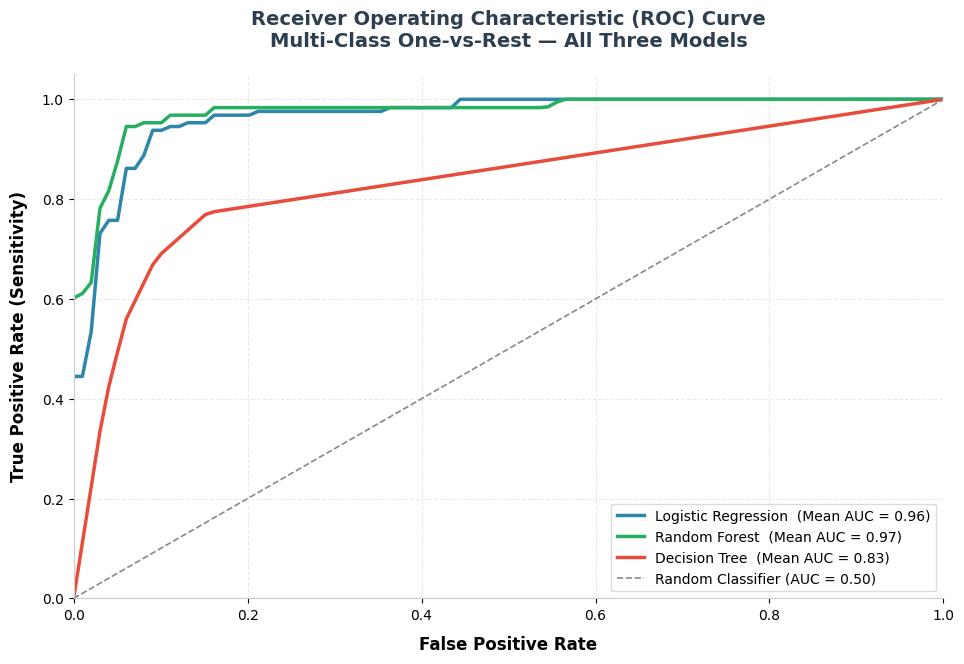

In [30]:
# ================================================
# CHART 11 — ROC CURVE — ALL THREE MODELS
# ================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = ['Distinction', 'Fail', 'Merit', 'Pass']

# Use the already-correct split variables from earlier in notebook
# X_train_sel, X_test_sel, y_train_res, y_test — already defined above
y_test_bin = label_binarize(y_test, classes=classes)

roc_models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42)
}
roc_colors = ['#2E86AB', '#27AE60', '#E74C3C']

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for (name, model), color in zip(roc_models.items(), roc_colors):
    model.fit(X_train_sel, y_train_res)

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test_sel)
    else:
        y_score = model.decision_function(X_test_sel)

    fpr, tpr, roc_auc_dict = {}, {}, {}
    for i, cls in enumerate(classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc_dict[i]   = auc(fpr[i], tpr[i])

    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.mean(
        [np.interp(mean_fpr, fpr[i], tpr[i]) for i in range(len(classes))],
        axis=0)
    mean_auc = np.mean(list(roc_auc_dict.values()))

    ax.plot(mean_fpr, mean_tpr, color=color, linewidth=2.5,
            label=f'{name}  (Mean AUC = {mean_auc:.2f})')

ax.plot([0, 1], [0, 1], color='#7F8C8D', linewidth=1.2,
        linestyle='--', label='Random Classifier (AUC = 0.50)')

ax.set_title('Receiver Operating Characteristic (ROC) Curve\n'
             'Multi-Class One-vs-Rest — All Three Models',
             fontsize=14, fontweight='bold', pad=20, color='#2C3E50')
ax.set_xlabel('False Positive Rate',
              fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('True Positive Rate (Sensitivity)',
              fontsize=12, fontweight='bold', labelpad=10)
ax.legend(fontsize=10, framealpha=0.7, loc='lower right',
          edgecolor='#CCCCCC')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')
ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.xaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC')
ax.set_axisbelow(True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout(pad=2.0)
plt.savefig('chart11_roc_curve.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

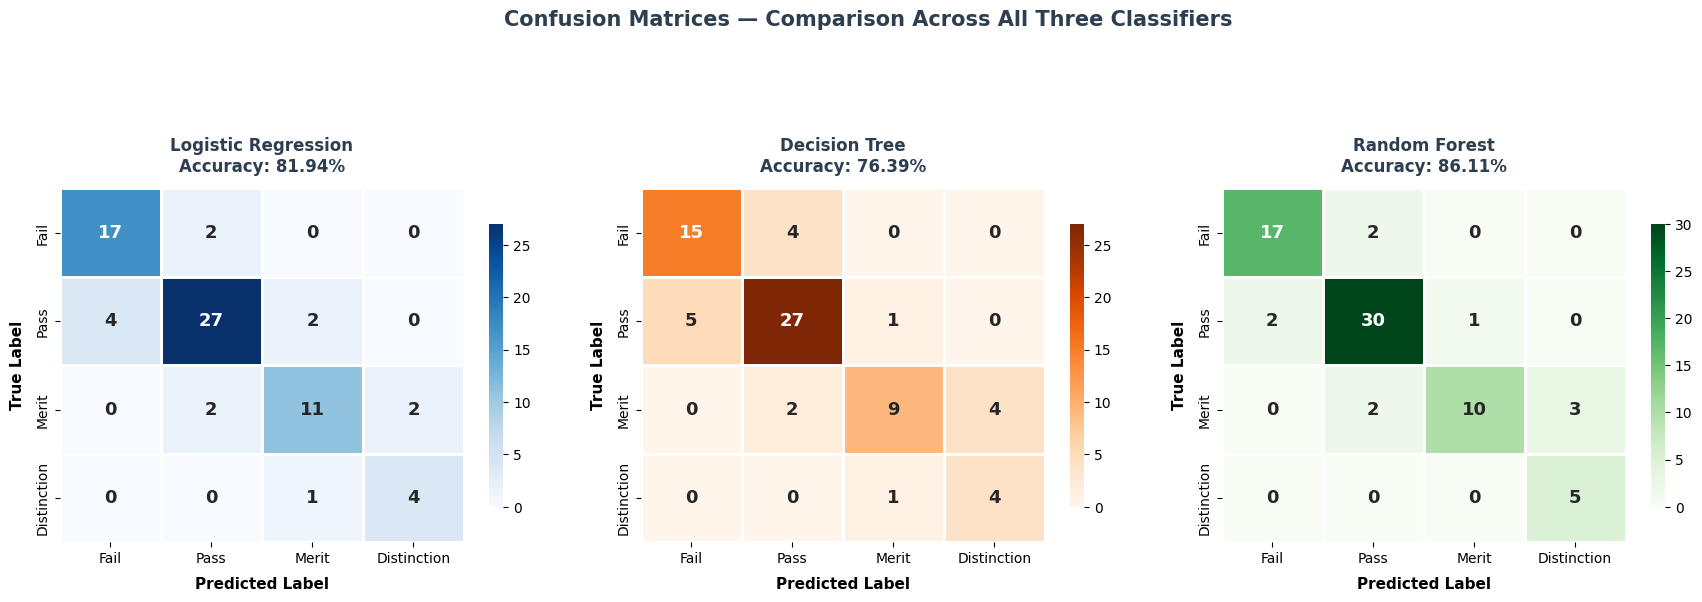

In [31]:
# ================================================
# CHART 12 — CONFUSION MATRICES — ALL THREE MODELS
# ================================================

# Uses X_train_sel, X_test_sel, y_train_res, y_test
# already defined correctly above — no data leak

labels = ['Fail', 'Pass', 'Merit', 'Distinction']

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=labels)
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels)

models_cms = {
    'Logistic Regression': (cm_lr, y_pred_lr, 'Blues'),
    'Decision Tree':       (cm_dt, y_pred_dt, 'Oranges'),
    'Random Forest':       (cm_rf, y_pred_rf, 'Greens'),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')

for ax, (name, (cm, y_pred, cmap)) in zip(axes, models_cms.items()):
    ax.set_facecolor('white')
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=labels, yticklabels=labels,
                ax=ax, linewidths=0.8, linecolor='white',
                annot_kws={'size': 13, 'weight': 'bold'},
                cbar_kws={'shrink': 0.8})
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}',
                 fontsize=12, fontweight='bold', pad=12, color='#2C3E50')
    ax.set_xlabel('Predicted Label',
                  fontsize=11, fontweight='bold', labelpad=8)
    ax.set_ylabel('True Label',
                  fontsize=11, fontweight='bold', labelpad=8)
    ax.tick_params(axis='both', labelsize=10)

plt.suptitle('Confusion Matrices — Comparison Across All Three Classifiers',
             fontsize=15, fontweight='bold', y=1.04, color='#2C3E50')
plt.tight_layout(pad=3.0)
plt.savefig('chart12_confusion_matrices.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

In [32]:
df.to_csv("student_cleaned_group27_updated.csv", index=False)